Question
Which of the 21 sensors have the strongest relationshio with engine aging?
Objective
Systematicaaly evaluate all 21 sensors using their relationship with engine life percentage and identify sensors thar should recieve further degradation analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
column_names=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}" for i in range(1,22)]

df=pd.read_csv('../data/raw/train_FD001.txt',sep=r'\s+',header=None)

df.columns=column_names

df["max_cycle"]=df.groupby("engine_id")["cycle"].transform("max")
df["life_percent"]= (df["cycle"]/df["max_cycle"])*100

In [6]:
df[["engine_id","cycle","max_cycle","life_percent"]].head()

,engine_id,cycle,max_cycle,life_percent
0,1,1,192,0.520833
1,1,2,192,1.041667
2,1,3,192,1.562500
3,1,4,192,2.083333
4,1,5,192,2.604167


In [7]:
sensor_columns= [f"sensor_{i}" for i in range(1,22)]

sensor_columns

['sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [8]:
sensor_std=df[sensor_columns].std()

sensor_std

sensor_1     0.000000e+00
sensor_2     5.000533e-01
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_7     8.850923e-01
sensor_8     7.098548e-02
sensor_9     2.208288e+01
sensor_10    0.000000e+00
sensor_11    2.670874e-01
sensor_12    7.375534e-01
sensor_13    7.191892e-02
sensor_14    1.907618e+01
sensor_15    3.750504e-02
sensor_16    3.469531e-18
sensor_17    1.548763e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    1.807464e-01
sensor_21    1.082509e-01
dtype: float64

In [14]:
sensor_correlation={}

for sensor in sensor_columns:
    sensor_correlation[sensor]= df["life_percent"].corr(df[sensor])

/Users/tiwafadeni/Desktop/Engineering Data Analysis Portfolio/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tiwafadeni/Desktop/Engineering Data Analysis Portfolio/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [15]:
sensor_analysis=pd.DataFrame({"Standard Deviation":sensor_std,"Correlation":pd.Series(sensor_correlation)})

In [16]:
sensor_analysis

,Standard Deviation,Correlation
sensor_1,0.000000e+00,NaN
sensor_2,5.000533e-01,6.321231e-01
sensor_3,6.131150e+00,6.160089e-01
sensor_4,9.000605e+00,7.115387e-01
sensor_5,5.329200e-15,2.524850e-16
sensor_6,1.388985e-03,1.214351e-01
sensor_7,8.850923e-01,-6.852334e-01
sensor_8,7.098548e-02,5.729824e-01
sensor_9,2.208288e+01,4.486737e-01
sensor_10,0.000000e+00,NaN


In [19]:
sensor_analysis.sort_values("Correlation",ascending=False).head(10)

,Standard Deviation,Correlation
sensor_11,0.267087,0.727496
sensor_4,9.000605,0.711539
sensor_15,0.037505,0.672931
sensor_17,1.548763,0.639694
sensor_2,0.500053,0.632123
sensor_3,6.131150,0.616009
sensor_13,0.071919,0.573969
sensor_8,0.070985,0.572982
sensor_9,22.082880,0.448674
sensor_14,19.076176,0.362541


In [20]:
sensor_analysis.sort_values("Correlation").head(10)

,Standard Deviation,Correlation
sensor_12,7.375534e-01,-7.018731e-01
sensor_7,8.850923e-01,-6.852334e-01
sensor_21,1.082509e-01,-6.668164e-01
sensor_20,1.807464e-01,-6.637412e-01
sensor_5,5.329200e-15,2.524850e-16
sensor_16,3.469531e-18,2.544575e-16
sensor_6,1.388985e-03,1.214351e-01
sensor_14,1.907618e+01,3.625414e-01
sensor_9,2.208288e+01,4.486737e-01
sensor_8,7.098548e-02,5.729824e-01


In [22]:
sensor_analysis["Absolute Correlation"]=sensor_analysis["Correlation"].abs()

sensor_analysis=sensor_analysis.sort_values("Absolute Correlation",ascending= False)

sensor_analysis

,Standard Deviation,Correlation,Absolute Correlation
sensor_11,2.670874e-01,7.274962e-01,7.274962e-01
sensor_4,9.000605e+00,7.115387e-01,7.115387e-01
sensor_12,7.375534e-01,-7.018731e-01,7.018731e-01
sensor_7,8.850923e-01,-6.852334e-01,6.852334e-01
sensor_15,3.750504e-02,6.729305e-01,6.729305e-01
sensor_21,1.082509e-01,-6.668164e-01,6.668164e-01
sensor_20,1.807464e-01,-6.637412e-01,6.637412e-01
sensor_17,1.548763e+00,6.396942e-01,6.396942e-01
sensor_2,5.000533e-01,6.321231e-01,6.321231e-01
sensor_3,6.131150e+00,6.160089e-01,6.160089e-01


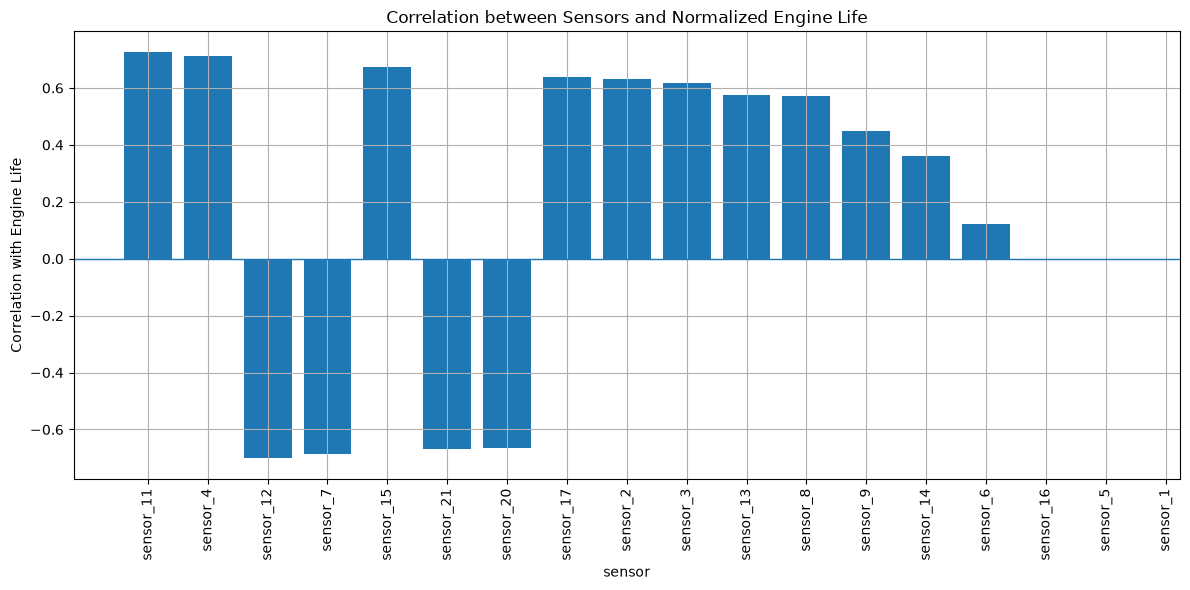

In [29]:
plt.figure(figsize=(12,6))

plt.bar(sensor_analysis.index,sensor_analysis['Correlation'])

plt.axhline(0,linewidth=1)
plt.xticks(rotation=90)
plt.title('Correlation between Sensors and Normalized Engine Life')
plt.xlabel('sensor')
plt.ylabel("Correlation with Engine Life")
plt.savefig("../figures/10_all_sensor_correlations.png",dpi=300,bbox_inches="tight")

plt.grid(True)
plt.tight_layout()

plt.show()


In [26]:
ranking=sensor_analysis.copy()
ranking["Rank"]=range(1,len(ranking)+1)

ranking=ranking[["Rank","Standard Deviation","Correlation","Absolute Correlation"]]

ranking

,Rank,Standard Deviation,Correlation,Absolute Correlation
sensor_11,1,2.670874e-01,7.274962e-01,7.274962e-01
sensor_4,2,9.000605e+00,7.115387e-01,7.115387e-01
sensor_12,3,7.375534e-01,-7.018731e-01,7.018731e-01
sensor_7,4,8.850923e-01,-6.852334e-01,6.852334e-01
sensor_15,5,3.750504e-02,6.729305e-01,6.729305e-01
sensor_21,6,1.082509e-01,-6.668164e-01,6.668164e-01
sensor_20,7,1.807464e-01,-6.637412e-01,6.637412e-01
sensor_17,8,1.548763e+00,6.396942e-01,6.396942e-01
sensor_2,9,5.000533e-01,6.321231e-01,6.321231e-01
sensor_3,10,6.131150e+00,6.160089e-01,6.160089e-01


In [27]:
ranking.head()

,Rank,Standard Deviation,Correlation,Absolute Correlation
sensor_11,1,0.267087,0.727496,0.727496
sensor_4,2,9.000605,0.711539,0.711539
sensor_12,3,0.737553,-0.701873,0.701873
sensor_7,4,0.885092,-0.685233,0.685233
sensor_15,5,0.037505,0.672931,0.672931


## Evaluation

The analysis of all 21 sensors provided several important findings. Sensors 4 and 11 supported our initial observations, demonstrating strong positive correlations with normalized engine life and consistent increasing trends as the engines aged. Sensor 11 had a correlation of 0.727, while Sensor 4 had a correlation of 0.712, making them two of the strongest positive indicators identified.

Sensor 15 also supported our initial observations. Despite having a very low standard deviation of 0.038, it demonstrated a relatively strong positive correlation with normalized engine life of 0.673. This demonstrates that high variability is not necessarily required for a sensor to provide useful information about engine aging; small but consistent changes can also be valuable.

Sensors 9 and 14 demonstrated relatively high standard deviations of 22.08 and 19.08, respectively, but had weaker correlations with normalized engine life of 0.490 and 0.363. Their behavior also varied considerably between engines. This suggests that high variability alone does not make a sensor a good degradation indicator, and further investigation is needed to determine what causes their inconsistent behavior.

Additionally, Sensors 7 and 12 were identified as potentially important indicators because they exhibited strong negative correlations with normalized engine life. Although these sensors decrease rather than increase as the engines age, the strength of their relationships suggests that they may contain useful information about engine degradation. These sensors were not identified during the initial analysis because the initial focus was primarily on sensors showing increasing trends.

Overall, the analysis demonstrates that both positive and negative relationships with engine life can potentially be useful for degradation monitoring. Based on the current results, Sensors 4, 11, 15, 7, and 12 should receive further investigation. However, correlation alone cannot establish that a sensor is a reliable degradation indicator. The next stage of analysis should determine whether these relationships remain consistent within individual engines and as the engines approach failure.